In [1]:
!pip install xarray netCDF4 emcee corner h5netcdf scikit-learn
import numpy as np
import xarray as xr
import pandas as pd
import emcee
import corner
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score



In [2]:
df_1 = pd.read_csv('params.csv')  # Load your data from a CSV file
df_1.head()
df_1['run_id'] = df_1['lut_path'].str.extract(r'lut_(\d+)\.dat$')[0].astype(int)
ds_nc = xr.open_dataset('combined_output.nc',engine='netcdf4')
df_nc = ds_nc.to_dataframe().reset_index()
df_nc = df_nc.dropna(subset=['PRECT'])
df_unified = pd.merge(
    df_1,
    df_nc,
    on='run_id',
    how='inner'           # only keep subjects that appear in BOTH files
)


In [3]:
# Step 1: compute mean of output variables for each run_id
output_cols = ['TGCLDIWP', 'LWCF', 'SWCF', 'CLDTOT', 'PRECT']
df_outputs = df_unified.groupby('run_id')[output_cols].mean().reset_index()

# Step 2: get one row of parameters per run_id (they dont change within a run)
param_cols = ['run_id', 'ds', 'rho_e', 'bas', 'micro_mg_vtrmi_factor', 'micro_mg_berg_eff_factor']
df_params = df_unified[param_cols].drop_duplicates(subset='run_id')

# Step 3: merge them together on run_id
df_model = pd.merge(
    df_params,
    df_outputs,
    on='run_id')

print(df_model.shape)
print(df_model.head())

(499, 11)
   run_id       ds    rho_e      bas  micro_mg_vtrmi_factor  \
0       0  2.43139  0.88300  1.93092                1.55731   
1       1  2.98594  0.80154  1.51213                1.82759   
2       2  1.69070  0.53283  1.96759                4.26234   
3       3  2.28133  0.71636  1.55453                2.53309   
4       4  2.20747  0.85695  1.43424                4.43978   

   micro_mg_berg_eff_factor  TGCLDIWP       LWCF       SWCF    CLDTOT  \
0                   0.10298  0.114449  39.054104 -64.122383  0.713200   
1                   0.47674  0.055845  10.422736 -39.265537  0.688813   
2                   0.50011  0.062612  26.243057 -46.960510  0.651257   
3                   0.89830  0.066999  27.498352 -46.397758  0.661900   
4                   0.65745  0.075053  30.412548 -51.234451  0.658562   

          PRECT  
0  3.164195e-08  
1  3.174044e-08  
2  3.272332e-08  
3  3.239926e-08  
4  3.213558e-08  


In [4]:
X = df_model[['ds', 'rho_e', 'bas', 'micro_mg_vtrmi_factor', 'micro_mg_berg_eff_factor']].values
y = df_model[['TGCLDIWP', 'LWCF', 'SWCF', 'CLDTOT', 'PRECT']].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (499, 5)
y shape: (499, 5)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train
emulator = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
emulator.fit(X_train_scaled, y_train)

# evaluate
y_pred = emulator.predict(X_test_scaled)
print("R² per output variable:")
for i, col in enumerate(output_cols):
    print(f"  {col}: {r2_score(y_test[:, i], y_pred[:, i]):.3f}")

R² per output variable:
  TGCLDIWP: 0.513
  LWCF: 0.677
  SWCF: 0.504
  CLDTOT: 0.330
  PRECT: 0.418


In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# degree=2 adds squared terms and interaction terms between parameters
# e.g. ds², ds×rho_e, rho_e² etc.
poly_emulator = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5))
])

poly_emulator.fit(X_train, y_train)
y_pred_poly = poly_emulator.predict(X_test)

print("R² with polynomial features:")
for i, col in enumerate(output_cols):
    print(f"  {col}: {r2_score(y_test[:, i], y_pred_poly[:, i]):.3f}")

R² with polynomial features:
  TGCLDIWP: 0.619
  LWCF: 0.881
  SWCF: 0.757
  CLDTOT: 0.344
  PRECT: 0.518


In [7]:
from sklearn.ensemble import RandomForestRegressor

rf_emulator = RandomForestRegressor(n_estimators=100, random_state=42)
rf_emulator.fit(X_train, y_train)
y_pred_rf = rf_emulator.predict(X_test)

print("R² with Random Forest:")
for i, col in enumerate(output_cols):
    print(f"  {col}: {r2_score(y_test[:, i], y_pred_rf[:, i]):.3f}")

R² with Random Forest:
  TGCLDIWP: 0.616
  LWCF: 0.914
  SWCF: 0.864
  CLDTOT: 0.363
  PRECT: 0.463


In [8]:
y_obs = df_model[output_cols].mean().values
yerr_obs = df_model[output_cols].std().values * 0.1  # 10% of std as uncertainty

print("Observed climate values we're trying to match:")
for i, col in enumerate(output_cols):
    print(f"  {col}: {y_obs[i]:.4f} ± {yerr_obs[i]:.4f}")

Observed climate values we're trying to match:
  TGCLDIWP: 0.0653 ± 0.0020
  LWCF: 24.3489 ± 0.7328
  SWCF: -47.0096 ± 0.6835
  CLDTOT: 0.6661 ± 0.0026
  PRECT: 0.0000 ± 0.0000


In [9]:
def log_likelihood(theta, emulator, y_obs, yerr_obs):
    # theta is one candidate set of parameter values
    # e.g. [ds=2.1, rho_e=0.7, bas=1.5, vtrmi=2.0, berg=0.4]
    
    # ask the emulator: if these were the true parameters,
    # what climate outputs would you predict?
    predicted = emulator.predict([theta])[0]   # shape: (5,)
    
    # compare prediction to real observed values
    # large difference = low likelihood (bad candidate)
    # small difference = high likelihood (good candidate)
    sigma2 = yerr_obs ** 2
    return -0.5 * np.sum((y_obs - predicted) ** 2 / sigma2 + np.log(sigma2))

def log_prior(theta):
    ds, rho_e, bas, vtrmi, berg = theta
    
    # use the actual min/max from your PPE data as bounds
    # walkers are not allowed outside the range the emulator was trained on
    if (df_model['ds'].min() < ds < df_model['ds'].max() and
        df_model['rho_e'].min() < rho_e < df_model['rho_e'].max() and
        df_model['bas'].min() < bas < df_model['bas'].max() and
        df_model['micro_mg_vtrmi_factor'].min() < vtrmi < df_model['micro_mg_vtrmi_factor'].max() and
        df_model['micro_mg_berg_eff_factor'].min() < berg < df_model['micro_mg_berg_eff_factor'].max()):
        return 0.0       # allowed - within training range
    return -np.inf       # not allowed - outside training range

def log_probability(theta, emulator, y_obs, yerr_obs):
    # check prior first (cheap operation)
    lp = log_prior(theta)
    
    # if outside allowed range, immediately reject
    if not np.isfinite(lp):
        return -np.inf
    
    # otherwise combine prior + likelihood
    return lp + log_likelihood(theta, emulator, y_obs, yerr_obs)

In [10]:

initial_guess = np.array([
    df_model['ds'].mean(),
    df_model['rho_e'].mean(),
    df_model['bas'].mean(),
    df_model['micro_mg_vtrmi_factor'].mean(),
    df_model['micro_mg_berg_eff_factor'].mean()
])

# find the single best parameter set before MCMC explores uncertainty
result = minimize(
    lambda theta: -log_likelihood(theta, rf_emulator, y_obs, yerr_obs),
    initial_guess
)

best_params = result.x
print("Best starting parameters:")
for i, col in enumerate(['ds', 'rho_e', 'bas', 'micro_mg_vtrmi_factor', 'micro_mg_berg_eff_factor']):
    print(f"  {col}: {best_params[i]:.4f}")

Best starting parameters:
  ds: 2.3336
  rho_e: 0.4551
  bas: 1.7055
  micro_mg_vtrmi_factor: 2.6012
  micro_mg_berg_eff_factor: 0.5504


In [11]:
nwalkers = 32   # number of walkers exploring simultaneously
ndim = 5        # number of unknown parameters

# scatter 32 walkers in a tiny cluster around the best starting point
# 1e-4 is a very small nudge so each walker starts slightly differently
pos = best_params + 1e-4 * np.random.randn(nwalkers, ndim)

In [12]:
# create the sampler
sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_probability,
    args=(rf_emulator, y_obs, yerr_obs)
)

# run it - 2000 steps per walker
sampler.run_mcmc(pos, 2000, progress=True)

100%|██████████| 2000/2000 [07:25<00:00,  4.49it/s]


State([[1.77095615 0.42527681 1.75971704 1.26791604 0.55045792]
 [2.3022334  0.13368754 1.83747898 0.64829835 0.64122895]
 [2.66319679 0.53819964 1.60103205 4.76512263 0.37064207]
 [1.72249771 0.36568258 1.44341916 3.15541914 0.36666192]
 [1.9332407  0.34151062 1.70091581 1.30079548 0.51388671]
 [2.02186906 0.3001081  1.94158636 1.65682307 0.99506386]
 [2.38755817 0.51012967 1.785062   1.05375608 0.39991388]
 [1.68135314 0.33907221 1.69462593 0.74810879 0.77970765]
 [1.72958459 0.50459929 1.47767972 4.49483357 0.45557969]
 [1.740962   0.37895384 1.72472697 1.27278764 0.73559159]
 [1.72620611 0.3029585  1.53396761 1.7605112  0.31824009]
 [1.74070533 0.3415689  1.73800094 1.56816068 0.54665636]
 [1.94378491 0.19030269 1.66611504 0.86219276 0.56723138]
 [2.46605346 0.58239794 1.66159285 0.93953534 0.45254962]
 [2.72854696 0.69238108 1.68512925 1.60832761 0.47005342]
 [2.76192896 0.7120923  1.64422416 1.25570345 0.52820368]
 [2.67782859 0.5423101  1.71787172 1.19389388 0.36190935]
 [1.7402

In [13]:
# check autocorrelation time - how many steps before walkers "forget" their start
tau = sampler.get_autocorr_time(quiet=True)
print("Autocorrelation times:", tau)

burnin = int(2 * np.max(tau))    # discard early steps before walkers settled
thin = int(0.5 * np.min(tau))    # keep only every nth sample for independence

# extract clean, independent samples
flat_samples = sampler.get_chain(discard=burnin, thin=thin, flat=True)
print("Final sample shape:", flat_samples.shape)
# e.g. (8000, 5) - 8000 independent samples, each with 5 parameter values

The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [148.59273392 155.50077908 164.0245329  176.17340871 168.3180757 ]


Autocorrelation times: [148.59273392 155.50077908 164.0245329  176.17340871 168.3180757 ]
Final sample shape: (704, 5)


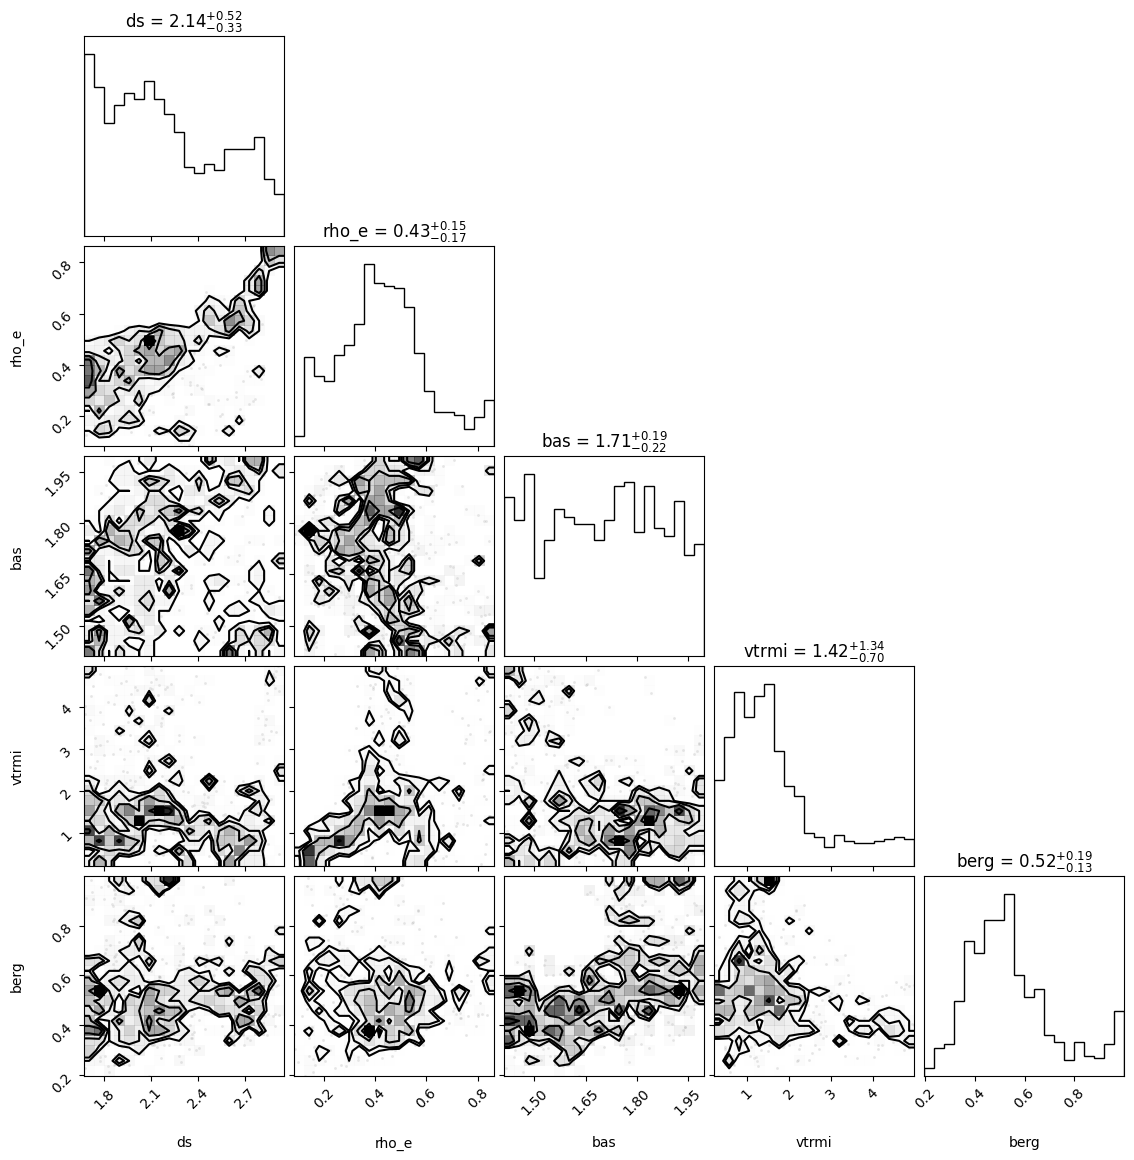

In [16]:
param_labels = ['ds', 'rho_e', 'bas', 'vtrmi', 'berg']

fig = corner.corner(
    flat_samples,
    labels=param_labels,
    show_titles=True,        # shows median ± uncertainty above each histogram
    title_kwargs={"fontsize": 12}
)
plt.show()

In [17]:
param_names = ['ds', 'rho_e', 'bas', 'micro_mg_vtrmi_factor', 'micro_mg_berg_eff_factor']

print("Posterior parameter estimates:")
for i, name in enumerate(param_names):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"  {name}: {mcmc[1]:.4f} +{q[1]:.4f} / -{q[0]:.4f}")

Posterior parameter estimates:
  ds: 2.1377 +0.5186 / -0.3322
  rho_e: 0.4259 +0.1493 / -0.1656
  bas: 1.7102 +0.1873 / -0.2165
  micro_mg_vtrmi_factor: 1.4187 +1.3425 / -0.6968
  micro_mg_berg_eff_factor: 0.5179 +0.1904 / -0.1330
